# Projeto 01 - Superstore Sales Analysis

## Objetivo

Realizar uma análise exploratória dos dados de vendas da Superstore para identificar padrões de comportamento, oportunidades de crescimento e gerar recomendações que auxiliem a tomada de decisão da empresa.

In [20]:
import pandas as pd
import numpy as np

In [21]:
df = pd.read_csv(
    r"C:\Users\higor\Projeto Vendas - Superstore Sales\Dataset\Sample - Superstore.csv",
    encoding="latin1"
)

In [22]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [24]:
new_columns = []
for colunas in df:
    colunas_strip = colunas.strip()
    colunas_lower = colunas_strip.lower()
    colunas_replace = colunas_lower.replace(' ', '_')
    new_columns.append(colunas_replace)


df.columns = new_columns

df.info()
#Os nomes das colunas foram padronizados para snake_case (minúsculas e underscore) visando melhorar a legibilidade e manter consistência ao longo da análise.


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   order_date     9994 non-null   str    
 3   ship_date      9994 non-null   str    
 4   ship_mode      9994 non-null   str    
 5   customer_id    9994 non-null   str    
 6   customer_name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   str    
 13  product_id     9994 non-null   str    
 14  category       9994 non-null   str    
 15  sub-category   9994 non-null   str    
 16  product_name   9994 non-null   str    
 17  sales          9994 non-null   float64
 18  quantity       9994

## Inspeção dos valores das colunas

Após padronizar os nomes das colunas, será realizada uma inspeção para verificar se os valores estão preenchidos de forma consistente e identificar possíveis inconsistências nos dados.

Para tornar essa etapa mais organizada e reutilizável, será criada uma função responsável por exibir informações importantes de cada coluna, como o tipo de dado, a quantidade de valores únicos, valores ausentes e a frequência de cada categoria, antes do início da análise exploratória dos dados (EDA).

## Column Value Inspection

After standardizing the column names, an inspection will be performed to verify that the values are consistently filled and to identify any potential data inconsistencies.

To make this step more organized and reusable, a function will be created to display key information about each column, such as its data type, the number of unique values, missing values, and the frequency of each category before starting the Exploratory Data Analysis (EDA).

In [25]:
def inspect_column(dataframe, column):
    print('=' * 50)
    print(f'Coluna: {column}')
    print(f'Tipo: {dataframe[column].dtype}')
    print(f'Valores únicos: {dataframe[column].nunique()}')
    print(f'Valores ausentes: {dataframe[column].isna().sum()}')
    print(dataframe[column].value_counts())

inspect_column(df, 'segment')
inspect_column(df, 'ship_mode')

Coluna: segment
Tipo: str
Valores únicos: 3
Valores ausentes: 0
segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64
Coluna: ship_mode
Tipo: str
Valores únicos: 4
Valores ausentes: 0
ship_mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


In [26]:
inspect_column(df, 'category')

Coluna: category
Tipo: str
Valores únicos: 3
Valores ausentes: 0
category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64


In [27]:
inspect_column(df, 'sub-category')

Coluna: sub-category
Tipo: str
Valores únicos: 17
Valores ausentes: 0
sub-category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64


In [28]:
inspect_column(df, 'region')
inspect_column(df, 'country')

Coluna: region
Tipo: str
Valores únicos: 4
Valores ausentes: 0
region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64
Coluna: country
Tipo: str
Valores únicos: 1
Valores ausentes: 0
country
United States    9994
Name: count, dtype: int64


In [29]:
inspect_column(df, 'state')

Coluna: state
Tipo: str
Valores únicos: 49
Valores ausentes: 0
state
California              2001
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 492
Ohio                     469
Florida                  383
Michigan                 255
North Carolina           249
Arizona                  224
Virginia                 224
Georgia                  184
Tennessee                183
Colorado                 182
Indiana                  149
Kentucky                 139
Massachusetts            135
New Jersey               130
Oregon                   124
Wisconsin                110
Maryland                 105
Delaware                  96
Minnesota                 89
Connecticut               82
Missouri                  66
Oklahoma                  66
Alabama                   61
Arkansas                  60
Rhode Island              56
Utah                      53
Mississippi               53
Sou

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   order_date     9994 non-null   str    
 3   ship_date      9994 non-null   str    
 4   ship_mode      9994 non-null   str    
 5   customer_id    9994 non-null   str    
 6   customer_name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   str    
 13  product_id     9994 non-null   str    
 14  category       9994 non-null   str    
 15  sub-category   9994 non-null   str    
 16  product_name   9994 non-null   str    
 17  sales          9994 non-null   float64
 18  quantity       9994

In [31]:
date_columns = ['order_date', 'ship_date']

for column in date_columns:
    df[column] = pd.to_datetime(df[column])

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   str           
 2   order_date     9994 non-null   datetime64[us]
 3   ship_date      9994 non-null   datetime64[us]
 4   ship_mode      9994 non-null   str           
 5   customer_id    9994 non-null   str           
 6   customer_name  9994 non-null   str           
 7   segment        9994 non-null   str           
 8   country        9994 non-null   str           
 9   city           9994 non-null   str           
 10  state          9994 non-null   str           
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   str           
 13  product_id     9994 non-null   str           
 14  category       9994 non-null   str           
 15  sub-category   9994 non-null   s

In [33]:
numeric_columns = ['sales', 'profit', 'quantity', 'discount']

df[numeric_columns].describe()

,sales,profit,quantity,discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


### Análise estatística inicial (`describe()`)

Foi utilizada a função `describe()` para obter um resumo estatístico das principais variáveis numéricas do conjunto de dados (`sales`, `profit`, `quantity` e `discount`).

As primeiras observações indicam que:

- A coluna **sales** apresenta alta dispersão dos valores, sugerindo a possível existência de valores extremos (outliers) que influenciam a média.
- A coluna **profit** possui registros com valores negativos, indicando vendas realizadas com prejuízo.
- A coluna **quantity** apresenta média e mediana próximas, sugerindo uma distribuição relativamente equilibrada.
- A coluna **discount** possui descontos entre **0% e 80%**, sendo que a maior parte dos registros apresenta descontos de até **20%**.

Essas observações são preliminares e serão investigadas nas próximas etapas da Análise Exploratória de Dados (EDA).

### Initial statistical analysis (`describe()`)

The `describe()` function was used to generate a statistical summary of the main numerical variables (`sales`, `profit`, `quantity`, and `discount`).

The initial observations indicate that:

- The **sales** column shows high variability, suggesting the possible presence of outliers influencing the mean.
- The **profit** column contains negative values, indicating transactions that resulted in a financial loss.
- The **quantity** column presents similar mean and median values, suggesting a relatively balanced distribution.
- The **discount** column ranges from **0% to 80%**, with most records showing discounts of up to **20%**.

These findings are preliminary and will be further investigated during the next stages of the Exploratory Data Analysis (EDA).

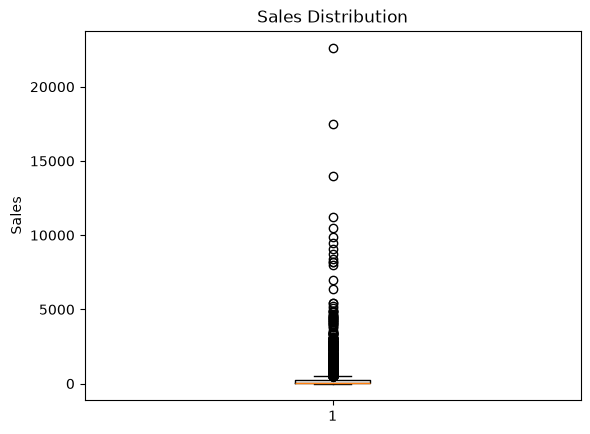

In [34]:
import matplotlib.pyplot as plt

plt.boxplot(df['sales'])
plt.title('Sales Distribution')
plt.ylabel('Sales')
plt.show()

### Sales — Boxplot

- O boxplot confirmou a presença de diversos valores atípicos na coluna `sales`.
- A maior parte das vendas está concentrada em valores relativamente baixos.
- Existem registros com valores significativamente superiores à distribuição principal, chegando a aproximadamente 22,7 mil.
- Esses valores podem influenciar significativamente medidas como a média.
- Os possíveis outliers não serão removidos neste momento; serão investigados para verificar se representam vendas legítimas ou possíveis inconsistências.

In [36]:
df_sales = df.groupby('category')['sales'].max().sort_values(ascending=False)
print(df_sales)

category
Technology         22638.480
Office Supplies     9892.740
Furniture           4416.174
Name: sales, dtype: float64


In [40]:
df_sales_sum = df.groupby('category')['sales'].sum().sort_values(ascending=False)
print(df_sales_sum)

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64


In [39]:
df_subcategory = df.groupby('sub-category')['sales'].max().sort_values(ascending=False)
print(df_subcategory)

sub-category
Machines       22638.480
Copiers        17499.950
Binders         9892.740
Supplies        8187.650
Phones          4548.810
Chairs          4416.174
Bookcases       4404.900
Tables          4297.644
Accessories     3347.370
Storage         2934.330
Appliances      2625.120
Furnishings     1336.440
Art             1113.024
Labels           786.480
Paper            733.950
Envelopes        604.656
Fasteners         93.360
Name: sales, dtype: float64


In [41]:
df_subcategory_sum = df.groupby('sub-category')['sales'].sum().sort_values(ascending=False)
print(df_subcategory_sum)

sub-category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: sales, dtype: float64


In [43]:
df_profit = df.groupby('sub-category')['profit'].sum().sort_values(ascending=False)
print(df_profit)

sub-category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: profit, dtype: float64


## Análise de Vendas e Lucro por Categoria e Subcategoria
## Sales and Profit Analysis by Category and Subcategory

### 🇧🇷 Observações

- Analisamos as categorias e subcategorias considerando:
  - Valor total de vendas (`sales`)
  - Lucro total (`profit`)
  - Maior venda individual (`max(sales)`)

- **Tecnologia** apresentou o maior valor total de vendas entre as categorias, seguida por **Móveis** e **Materiais de Escritório**.

- Entre as subcategorias, **Phones** apresentou o maior valor acumulado de vendas, seguido por **Chairs**, **Storage**, **Tables** e **Binders**.

- No ranking de lucro, os resultados foram diferentes:
  - **Copiers** apresentou o maior lucro total.
  - **Phones** ficou em segundo lugar.
  - **Accessories** ficou em terceiro.

- Foram identificadas subcategorias com **lucro negativo**:
  - **Tables:** -17.725,48
  - **Bookcases:** -3.472,56
  - **Supplies:** -1.189,10

- **Tables** apresentou um resultado especialmente relevante: está entre as subcategorias com maior volume total de vendas, mas apresentou o **maior prejuízo**.

### 🇧🇷 Próxima investigação

- Relacionar `category` e `sub_category`.
- Comparar vendas totais e lucro dentro de cada categoria.
- Investigar a relação entre **desconto (`discount`) e lucro (`profit`)**, especialmente nas subcategorias com prejuízo.

---

### 🇺🇸 Observations

- We analyzed the categories and sub-categories based on:
  - Total sales value (`sales`)
  - Total profit (`profit`)
  - Highest individual sale (`max(sales)`)

- **Technology** generated the highest total sales among the categories, followed by **Furniture** and **Office Supplies**.

- Among the sub-categories, **Phones** generated the highest total sales, followed by **Chairs**, **Storage**, **Tables**, and **Binders**.

- The profit ranking showed different results:
  - **Copiers** generated the highest total profit.
  - **Phones** ranked second.
  - **Accessories** ranked third.

- Some sub-categories presented **negative profit**:
  - **Tables:** -17,725.48
  - **Bookcases:** -3,472.56
  - **Supplies:** -1,189.10

- **Tables** presented a particularly relevant result: it is among the sub-categories with the highest total sales, but generated the **largest loss**.

### 🇺🇸 Next Investigation

- Relate `category` and `sub_category`.
- Compare total sales and profit within each category.
- Investigate the relationship between **discount (`discount`) and profit (`profit`)**, especially for sub-categories with negative profit.

In [45]:
top5_sales = (
    df.groupby('sub-category')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

df[df['sub-category'].isin(top5_sales.index)][
    ['category', 'sub-category']
].drop_duplicates().sort_values('sub-category')

,category,sub-category
8,Office Supplies,Binders
1,Furniture,Chairs
7,Technology,Phones
4,Office Supplies,Storage
3,Furniture,Tables
